In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from astropy.io import fits
from astropy.io import fits
from astropy.table import Table
import json
import sys

In [2]:
sys.path.append(str(Path().resolve() / 'py_modules')) 

import list_maps_plots

# Carina Data

In [3]:
line        = '[S II]'
lambda_rest = 6730.8
line_id     = 'S'

In [4]:
# Data from observations
bins        = 0

region     = 'NGC 3375'
name_reg   = 'Carina'
reg_id     = 'Car'
inst       = 'FLAMES'
inst_id    = 'FLA'
type_obj   = 'H II region'

pix        = 0   # Instrument resolution [arcsec/pix]
dist       = 2130 # Distance [parsecs]
s0_        = 0.9    # proposed seeing

pc         = dist*(2*np.pi) / (360 * 60 * 60)
s0         = (s0_*pc)

#Since we are working with scatter adata there is no binning that can be applied
name_file    =  inst_id + '-' + reg_id + '-' + line_id 
name_id      =  inst_id + '-' + reg_id + '-' + line_id 
print(name_file)
print(name_id)

FLA-Car-S
FLA-Car-S


In [5]:
# Dr will snippet for stars and other puntual objects

points_of_interest = {
    "eta Car": [161.26517, -59.684425],
    "Tr 14": [160.98911, -59.547698],
    "WR 25": [161.0433, -59.719735],
    "Finger": [161.13133, -59.664035],
}
def mark_points(ax):
    for label, c in points_of_interest.items():
        ax.plot(c[0], c[1], marker='+', markersize='12', color='k')

In [6]:
_data = json.load(open('observations/'+ name_file + '-l.json'))
_line = pd.DataFrame(_data[name_file])
_line.columns = ['RAdeg', 'DEdeg', 'V_mean','log_F','sigma']


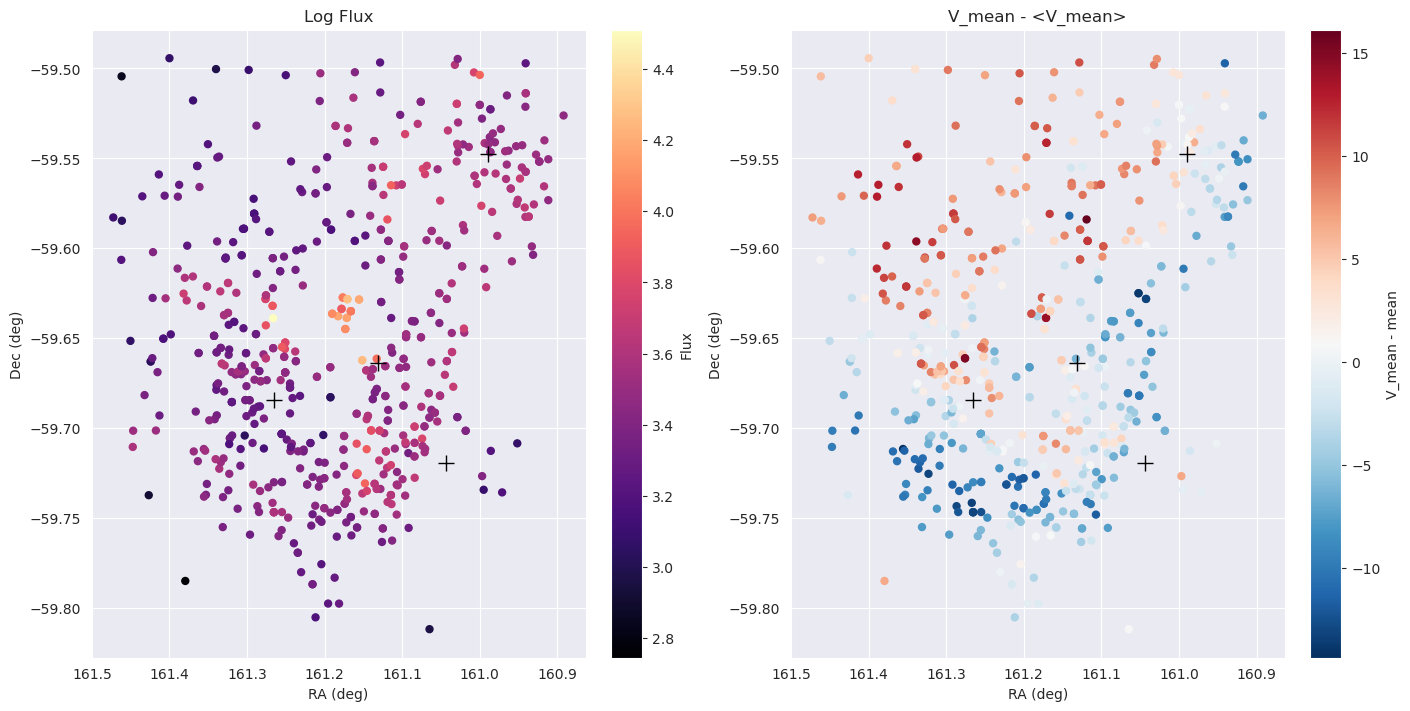

In [7]:
fig, ax = list_maps_plots.plot_panels(_line, mark_func=mark_points)
plt.show()

In [8]:
N = np.sqrt((_line.RAdeg.max()-_line.RAdeg.min())*(_line.DEdeg.max()-_line.DEdeg.min())) * pc * 3600
sig       = _line['V_mean'].std()

In [9]:
t         = Table.from_pandas(_line.reset_index(drop=True))
table_hdu = fits.BinTableHDU(t, name=name_file)

In [10]:
primary = fits.PrimaryHDU()
primary.header["FILE"]       = (name_file, "Fits file name")
primary.header["NAME_ID"]    = (name_id, "pipeline identifier")
primary.header["REG"]        = (region, "Region catalog name")
primary.header["NAME_REG"]   = (name_reg, "Region name")
primary.header["REG_ID"]     = (reg_id, "Region identifier")
primary.header["TYPE_OBJ"]   = (type_obj, "Type object")
primary.header["DIST"]       = (dist, "Distance in parsecs")
primary.header["INSTR"]      = (inst, "Instrument")
primary.header["LINE"]       = (line, "Emission line name")
primary.header["LINE_ID"]    = (line_id, "Emission line identifier")
primary.header["L_REST"]= (lambda_rest, "Emission line name")
primary.header["SIG"]        = (sig, "Standard deviation vel map")
primary.header["SIG2"]       = (sig**2, "Vel Variance map")
primary.header["S0"]         = (s0, "Atmospheric seeing")
primary.header["BOX_SIZE"]   = (N, "Observational box_size")
primary.header["PC"]         = (pc, "parsec convertion")
primary.header["PIX"]        = (pix, "Instrument pixel scale")
primary.header["BINSIZE"]    = (bins, "Spatial binning factor")
#hdr["noise"]     = (noise, "Instrumental noise")
#hdr["m3D"]       = (m3D, "k = 3 + m3D")
#hdr["ra"]        = (ra, "Artificial correlation length")
#primary.header["SEED1"]     = (randomseed_vv, "Random seed velocity")
#primary.header["SEED2"]     = (randomseed_sb, "Random seed surfavebrightness")
primary.header["AUTHOR"]     = ("J. Garcia-Vazquez", "File creator")

In [11]:
hdul = fits.HDUList([primary, table_hdu])
hdul.writeto("fits_ready/" + name_file + ".fits", overwrite=True)

In [12]:
with fits.open("fits_ready/" + name_file + ".fits") as hdul:
    hdul.info()

Filename: fits_ready/FLA-Car-S.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      23   ()      
  1  FLA-CAR-S     1 BinTableHDU     19   615R x 5C   [D, D, D, D, D]   
